# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import  PredefinedSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = '2023-11-08', '2024-08-21'
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = True
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.402 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-11-08 to 2024-08-21

Target column: FN2O_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,NaN,2.367268,2.367268,1.568481,-0.798787,-0.111997,-0.111997,-0.111997,NaN,NaN,NaN,B,certain,1.0,...,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,30.0,22.0,0.300700,5.004348,1032
2023-11-08 00:45:00,NaN,NaN,2.238080,2.238080,1.591144,-0.646936,0.100302,0.100302,0.100302,0.100302,0.100302,0.100302,B,certain,1.0,...,0.016644,-2.340741,0.001028,0.291943,0.0,0.0,2.179702,0.983564,29.0,22.0,30.0,22.0,0.300704,5.004376,1033
2023-11-08 01:15:00,NaN,NaN,2.207177,2.207177,1.586392,-0.620786,0.239428,0.239428,0.239428,0.239428,0.239428,0.239428,B,certain,1.0,...,0.138010,-0.829823,0.242660,0.618842,0.0,0.0,2.174248,0.980476,29.0,22.0,30.0,22.0,0.300709,5.004405,1034
2023-11-08 01:45:00,NaN,NaN,2.186978,2.186978,1.587581,-0.599397,-0.184917,-0.184917,-0.184917,NaN,NaN,NaN,B,certain,1.0,...,0.307449,-0.724752,0.260016,0.686303,0.0,0.0,2.168807,0.977400,29.0,22.0,30.0,22.0,0.300714,5.004433,1035
2023-11-08 02:15:00,NaN,NaN,2.179536,2.179536,1.584012,-0.595524,0.358358,0.358358,0.358358,0.358358,0.358358,0.358358,B,certain,1.0,...,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,30.0,22.0,0.300718,5.004462,1036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 21:45:00,NaN,NaN,4.338262,4.338262,4.553706,0.215444,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.707135,0.024579,-0.259299,-0.314632,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14851
2024-08-21 22:15:00,NaN,NaN,4.139963,4.139963,4.508099,0.368136,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.744187,0.026603,-0.248552,-0.346094,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14852
2024-08-21 22:45:00,NaN,NaN,4.134058,4.134058,4.478950,0.344892,1.691333,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.720830,0.028865,-0.235925,-0.360680,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14853


# CLEAN DATA

In [4]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Filtered parcel_certainty=='certain': 4863/5511 rows kept


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:45:00,NaN,NaN,2.238080,2.238080,1.591144,-0.646936,0.100302,0.100302,0.100302,0.100302,0.100302,0.100302,B,certain,1.0,...,0.016644,-2.340741,0.001028,0.291943,0.0,0.0,2.179702,0.983564,29.0,22.0,30.0,22.0,0.300704,5.004376,1033
2023-11-08 01:15:00,NaN,NaN,2.207177,2.207177,1.586392,-0.620786,0.239428,0.239428,0.239428,0.239428,0.239428,0.239428,B,certain,1.0,...,0.138010,-0.829823,0.242660,0.618842,0.0,0.0,2.174248,0.980476,29.0,22.0,30.0,22.0,0.300709,5.004405,1034
2023-11-08 02:15:00,NaN,NaN,2.179536,2.179536,1.584012,-0.595524,0.358358,0.358358,0.358358,0.358358,0.358358,0.358358,B,certain,1.0,...,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,30.0,22.0,0.300718,5.004462,1036
2023-11-08 03:15:00,NaN,NaN,1.651816,1.651816,1.570877,-0.080939,0.070120,0.070120,0.070120,0.070120,0.070120,0.070120,B,certain,1.0,...,0.059082,0.121729,0.069218,0.542432,0.0,0.0,2.152567,0.968238,29.0,22.0,30.0,22.0,0.300727,5.004519,1038
2023-11-08 04:15:00,NaN,NaN,1.563341,1.563341,1.543164,-0.020176,-0.545573,-0.545573,-0.545573,-0.545573,-0.545573,-0.545573,B,certain,1.0,...,0.115496,0.390843,0.393405,0.937131,0.0,0.0,2.141808,0.962185,29.0,22.0,30.0,22.0,0.300737,5.004576,1040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 15:15:00,-0.536841,-0.536841,-0.536841,-0.536841,5.117683,5.654524,1.050287,1.050287,1.050287,1.050287,1.050287,1.050287,B,certain,1.0,...,-1.664014,-0.261534,-0.312375,-0.314981,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14838
2024-08-21 15:45:00,NaN,NaN,0.378920,0.378920,5.125717,4.746798,1.403125,1.403125,1.403125,1.403125,1.403125,1.403125,B,certain,1.0,...,-1.698194,-0.283878,-0.344184,-0.290028,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14839
2024-08-21 16:15:00,0.748269,0.748269,0.748269,0.748269,5.114525,4.366256,1.444844,1.444844,1.444844,1.444844,1.444844,1.444844,B,certain,1.0,...,-1.706350,-0.275155,-0.311697,-0.262727,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14840


# SELECT FEATURES

In [5]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# 'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_U50_f_reddyproc_roll3hsum'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set

Training rows (complete-case): 4863/4863


,GPP_NT_CUT_50_gfXG_QCF0,ta,timesince_prec,ts_0.3_gfXG,wfps_0.05_gfXG,crop,timesince_soil_preparation,timesince_sowing,ts_0.15_gfXG_lag3h,NEE_L3.3_CUT_50_QCF_gfXGBoost_roll6hsum,RECO_NT_CUT_50_gfXG_QCF0_roll6hmean,GPP_NT_CUT_50_gfXG_QCF0_roll6hsum,ts_0.15_gfXG_roll9hmean,ts_0.3_gfXG_roll3hmean,wfps_0.05_gfXG_roll3hmean,...,wfps_0.3_gfXG_lag6h_roll3hmean,wfps_0.3_gfXG_lag6h_roll6hmean,wfps_0.3_gfXG_lag9h_roll3hmean,wfps_0.3_gfXG_lag9h_roll9hmean,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,id,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:45:00,-0.646936,5.966667,13.0,10.933558,45.965144,1.0,21,21,11.309557,4.605348,1.586561,-0.902183,11.031759,11.206185,46.457919,...,43.814184,43.345011,42.875837,42.872142,0.860526,-0.241229,0.291943,0.0,0.0,2.179702,0.983564,29.0,1033,1.0,0.100302
2023-11-08 01:15:00,-0.620786,5.833333,14.0,10.941941,45.768440,1.0,21,21,11.240501,6.812526,1.585967,-1.579590,10.945262,11.223187,46.203886,...,43.945203,43.434384,42.923565,42.887940,0.363886,0.902289,0.618842,0.0,0.0,2.174248,0.980476,29.0,1034,1.0,0.239428
2023-11-08 02:15:00,-0.595524,5.766667,16.0,11.114241,45.888163,1.0,21,21,10.543236,11.179039,1.583892,-2.927533,10.783552,11.135539,45.930307,...,44.110782,43.579530,43.048278,42.919670,0.750873,1.037005,0.695635,0.0,0.0,2.163380,0.974334,29.0,1036,1.0,0.358358
2023-11-08 03:15:00,-0.080939,5.400000,18.0,10.794777,45.847515,1.0,21,21,9.815343,14.483459,1.580225,-3.231892,10.616063,10.949933,45.870280,...,43.698653,43.575533,43.452413,43.052427,0.507260,1.243841,0.542432,0.0,0.0,2.152567,0.968238,29.0,1038,1.0,0.070120
2023-11-08 04:15:00,-0.020176,4.633333,20.0,10.725005,45.843005,1.0,21,21,9.790032,17.627586,1.575130,-3.358380,10.466501,10.881700,45.867461,...,43.241828,43.593515,43.945203,43.227380,0.627440,1.279728,0.937131,0.0,0.0,2.141808,0.962185,29.0,1040,1.0,-0.545573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 15:15:00,5.654524,21.536667,114.0,19.990000,30.527820,2.0,17,60,20.299259,-7.179996,4.960565,52.055190,20.371769,19.927159,31.050930,...,42.844291,42.848872,42.853454,42.880932,-2.680999,-4.738651,-0.314981,0.0,0.0,0.000000,0.000000,0.0,14838,1.0,1.050287
2024-08-21 15:45:00,4.746798,21.616667,115.0,20.003703,30.320408,2.0,17,60,20.369629,-9.250203,4.987298,54.446190,20.409671,19.942221,30.841061,...,42.836428,42.843847,42.851266,42.880479,-2.824936,-4.761262,-0.290028,0.0,0.0,0.000000,0.000000,0.0,14839,1.0,1.403125
2024-08-21 16:15:00,4.366256,21.413333,116.0,20.029999,30.092192,2.0,17,60,20.405926,-7.526567,5.010974,56.205517,20.457675,19.962345,30.627781,...,42.822947,42.840802,42.858656,42.879553,-2.975469,-4.827537,-0.262727,0.0,0.0,0.000000,0.000000,0.0,14840,1.0,1.444844


# IMBALANCE HANDLING

## UNDER SAMPLING

In [6]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

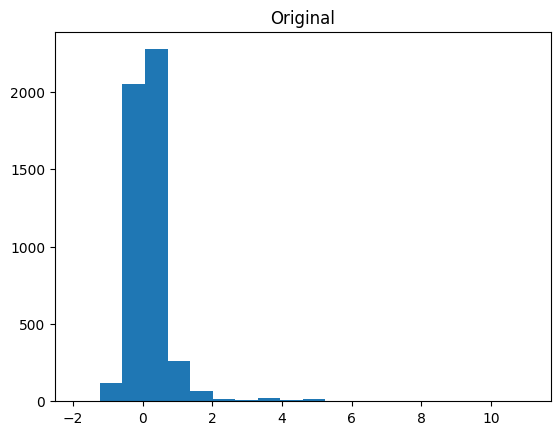

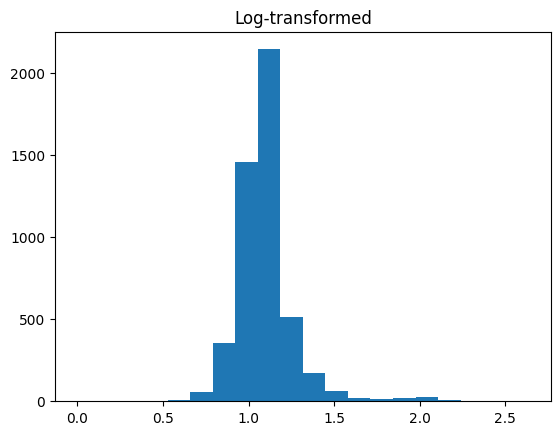

Applied log1p transform (shift=-1.869).


In [7]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

# CROSS-VAL SPLITS


Using block size of 5 time steps for CV splits.

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.099–0.101


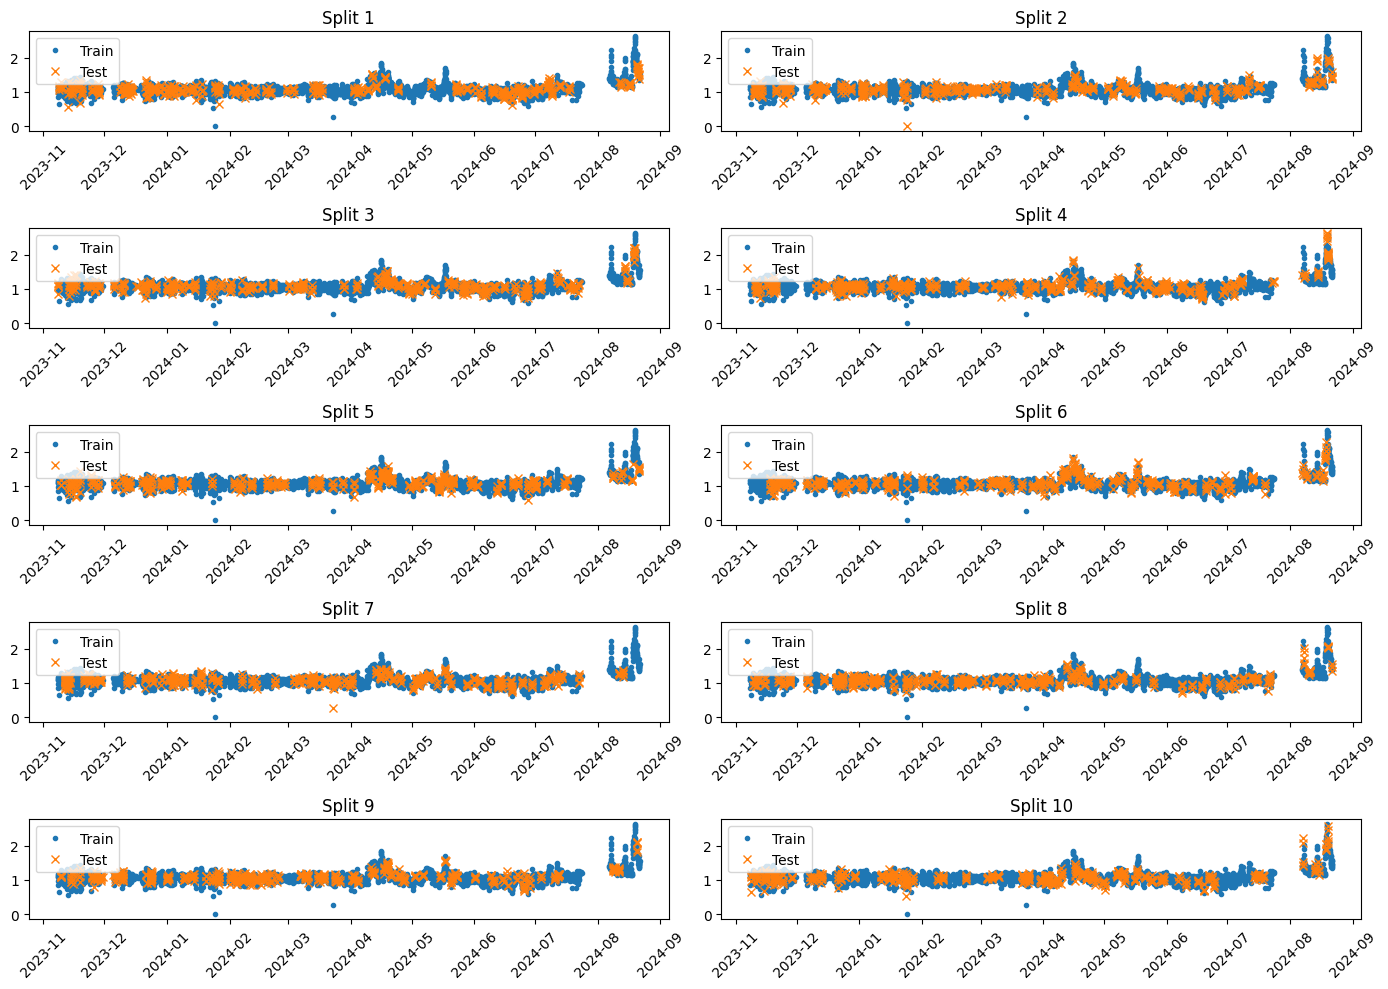

In [8]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6)
print(f"\nUsing block size of {block_size} time steps for CV splits.\n")
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [9]:
# Convert custom CV splits to PredefinedSplit for Scikit-Learn
test_fold = np.full(len(X), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
ps = PredefinedSplit(test_fold)

# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=-1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=-1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=100,      # number of random tries
    cv=ps,           # Uses your exact time-blocks
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best RMSE: 0.0938
Best Params: {'colsample_bytree': np.float64(0.7323592099410596), 'gamma': np.float64(0.03177917514301182), 'learning_rate': np.float64(0.03609823217156622), 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 198, 'subsample': np.float64(0.8365191150830908)}


# EXPORT 

In [10]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-28 12:25:32
